# 📊 Оценка на модела и метрики

## 🔍 Въведение
Този notebook е посветен на изчерпателна оценка на обучения MLP модел за прогнозиране на продажби. Оценката включва както стандартни regression метрики, така и по-усъвършенствани показатели за грешка, анализ на residuals, стабилност на прогнозите при различни конфигурации и сравнение с baseline модели.

---

## 🎯 Цели
Основната цел на този етап е да се оцени колко добре обучената невронна мрежа (MLP) прогнозира нови данни и дали прогнозите са стабилни и надеждни. Това включва:
- ✅ Количествено оценяване: чрез RMSE, MAE, WAPE, WRMSSE
- ✅ Качествено оценяване: чрез residuals, стабилност, comparison с baseline
- ✅ Бизнес проверка: дали прогнозите имат реална стойност и не предизвикват проблеми

---

## 📋 План на notebook-а

| Секция | Описание |
|--------|----------|
| **0. Setup** | Импортиране на библиотеки, настройка на пътища |
| **1. Зареждане на модел и данни** | Зареждане на обучения модел и test данни |
| **2. Изчисляване на regression метрики** | RMSE, MAE, WAPE, WRMSSE |
| **3. Анализ на residuals** | Визуализация и анализ на грешките |
| **4. Анализ на стабилност** | Confidence intervals и stability при различни seeds |
| **5. Сравнение с baseline модел** | Moving average, Linear regression, Naive forecast |
| **6. Бизнес-интерпретация** | Анализ на практическата приложимост |
| **7. Резюме и заключения** | Обобщение на резултатите |

---


## 0. Setup


In [ ]:
import torch
import os
os.environ["KERAS_BACKEND"] = "torch"

from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# ML и метрики
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
import keras
from keras.models import load_model

# Визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Статистика
from scipy import stats
from scipy.stats import normaltest

# Проектови пътища
# Определяне на root директорията (работи независимо от текущата директория)
if Path.cwd().name == "models":
    PROJ_ROOT = Path.cwd().resolve().parent
else:
    PROJ_ROOT = Path.cwd().resolve()

DATA_PROCESSED = PROJ_ROOT / "data" 
MODELS_DIR = PROJ_ROOT / "models"
REPORTS_DIR = PROJ_ROOT / "reports"

# Поддиректории в models/
TRAINED_MODELS_DIR = MODELS_DIR / "trained_models"
PREPROCESSING_DIR = MODELS_DIR / "preprocessing"
EVALUATION_METRICS_DIR = MODELS_DIR / "evaluation" / "metrics"
EVALUATION_VIZ_DIR = MODELS_DIR / "evaluation" / "visualizations"
EVALUATION_REPORTS_DIR = MODELS_DIR / "evaluation" / "reports"

# Създаване на директории (ако не съществуват)
for dir_path in [MODELS_DIR, REPORTS_DIR, TRAINED_MODELS_DIR, PREPROCESSING_DIR, 
                 EVALUATION_METRICS_DIR, EVALUATION_VIZ_DIR, EVALUATION_REPORTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

# Debug информация за пътищата
print(f"📁 Проект root: {PROJ_ROOT}")
print(f"📁 Models директория: {MODELS_DIR}")
print(f"📁 Data директория: {DATA_PROCESSED}")
print(f"📁 Trained models: {TRAINED_MODELS_DIR}")
print(f"📁 Evaluation results: {MODELS_DIR / 'evaluation'}")

# Seed за възпроизводимост
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

# Настройки за визуализация
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Дефиниране на custom метрика, използвана при обучение на модела
def root_mean_squared_error(y_true, y_pred):
    """Custom RMSE метрика, използвана при обучение на модела"""
    return keras.ops.sqrt(keras.ops.mean(keras.ops.square(y_pred - y_true)))

print(f"✅ Setup завършен")
print(f"Keras backend: {keras.config.backend()}")
print(f"CUDA available: {torch.cuda.is_available()}")


📁 Проект root: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting
📁 Models директория: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models
📁 Data директория: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/data
✅ Setup завършен
Keras backend: torch
CUDA available: False


## 1. Зареждане на модел и данни

Зареждаме обучения MLP модел и test данните за оценка.


In [ ]:
# Зареждане на модел
# Опитваме се да заредим най-добрия модел, ако не съществува - опитваме се с другия
model_path = TRAINED_MODELS_DIR / "best_mlp_model.keras"
if not model_path.exists():
    model_path = TRAINED_MODELS_DIR / "mlp_model_final_v3.keras"
    if not model_path.exists():
        raise FileNotFoundError(
            f"Моделът не е намерен! Проверете дали съществува един от следните файлове:\n"
            f"  - {TRAINED_MODELS_DIR / 'best_mlp_model.keras'}\n"
            f"  - {TRAINED_MODELS_DIR / 'mlp_model_final_v3.keras'}"
        )

print(f"📂 Зареждане на модел: {model_path}")
print(f"   Пълен път: {model_path.resolve()}")

# Зареждане на модела с custom метрика
# Трябва да предоставим custom_objects, защото моделът е обучен с custom метрика
model = load_model(
    str(model_path),
    custom_objects={'root_mean_squared_error': root_mean_squared_error},
    compile=True  # Компилираме модела с оригиналните метрики
)
print("✅ Моделът е зареден успешно!")

# Зареждане на данни
processed_data_path = DATA_PROCESSED / "processed_data.pkl"
print(f"\n📂 Зареждане на данни: {processed_data_path}")

with open(processed_data_path, "rb") as f:
    data = pickle.load(f)

X_test_scaled = data["X_test_scaled"]
y_test = data["y_test"]

# Конвертиране към numpy arrays (ако са pandas)
if isinstance(X_test_scaled, pd.DataFrame):
    X_test_scaled = X_test_scaled.values
if isinstance(y_test, pd.Series):
    y_test = y_test.values

# Конвертиране към float32
X_test_scaled = X_test_scaled.astype("float32")
y_test = y_test.astype("float32")

print(f"✅ Данните са заредени!")
print(f"   X_test_scaled: {X_test_scaled.shape}")
print(f"   y_test: {y_test.shape}")

# Генериране на прогнози
print(f"\n Генериране на прогнози...")
y_pred = model.predict(X_test_scaled, batch_size=1024, verbose=0)
y_pred = y_pred.flatten()

print(f"✅ Прогнозите са готови!")
print(f"   y_pred shape: {y_pred.shape}")


📂 Зареждане на модел: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/best_mlp_model.keras
   Пълен път: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/best_mlp_model.keras
✅ Моделът е зареден успешно!

📂 Зареждане на данни: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/data/processed_data.pkl
✅ Данните са заредени!
   X_test_scaled: (162155, 36)
   y_test: (162155,)

🔮 Генериране на прогнози...
✅ Прогнозите са готови!
   y_pred shape: (162155,)


## 2. Изчисляване на regression метрики

Regression метриките са основният инструмент за количествено измерване на точността на модела. Ще изчислим:
- **RMSE** (Root Mean Squared Error) - по-чувствителен към големи грешки
- **MAE** (Mean Absolute Error) - по-robust към outliers
- **WAPE** (Weighted Absolute Percentage Error) - процентна грешка, нормализирана спрямо действителните стойности
- **WRMSSE** (Weighted Root Mean Squared Scaled Error) - претеглена версия на RMSE


In [10]:
def calculate_rmse(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_mae(y_true, y_pred):
    """Mean Absolute Error"""
    return mean_absolute_error(y_true, y_pred)

def calculate_wape(y_true, y_pred):
    """Weighted Absolute Percentage Error"""
    # Избягваме деление на нула
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    numerator = np.abs(y_true[mask] - y_pred[mask]).sum()
    denominator = np.abs(y_true[mask]).sum()
    return (numerator / denominator) * 100 if denominator > 0 else np.nan

def calculate_wrmsse(y_true, y_pred):
    """Weighted Root Mean Squared Scaled Error"""
    # Изчисляваме RMSE за всеки уникален елемент (ако имаме групова структура)
    # За сега използваме общ RMSE, нормализиран спрямо средната стойност
    rmse = calculate_rmse(y_true, y_pred)
    mean_y = np.abs(y_true).mean()
    return (rmse / mean_y) * 100 if mean_y > 0 else np.nan

def calculate_mape(y_true, y_pred):
    """Mean Absolute Percentage Error (за сравнение)"""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Изчисляване на всички метрики
metrics = {
    "RMSE": calculate_rmse(y_test, y_pred),
    "MAE": calculate_mae(y_test, y_pred),
    "WAPE": calculate_wape(y_test, y_pred),
    "WRMSSE": calculate_wrmsse(y_test, y_pred),
    "MAPE": calculate_mape(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
}

print("📊 Regression метрики върху test set:\n")
for metric_name, metric_value in metrics.items():
    if not np.isnan(metric_value):
        if metric_name in ["WAPE", "WRMSSE", "MAPE"]:
            print(f"   {metric_name:10s}: {metric_value:8.4f}%")
        else:
            print(f"   {metric_name:10s}: {metric_value:8.4f}")
    else:
        print(f"   {metric_name:10s}: N/A")

# Запазване на метриките
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(EVALUATION_METRICS_DIR / "evaluation_metrics.csv", index=False)
print(f"\n✅ Метриките са запазени в: {MODELS_DIR / 'evaluation_metrics.csv'}")


📊 Regression метрики върху test set:

   RMSE      :   2.2472
   MAE       :   0.9015
   WAPE      :  60.2911%
   WRMSSE    : 233.9302%
   MAPE      :  61.3386%
   MSE       :   5.0499

✅ Метриките са запазени в: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/evaluation_metrics.csv


### 2.1. Интерпретация на метриките

**RMSE (Root Mean Squared Error):**
- Колкото по-нисък е RMSE, толкова по-точни са прогнозите
- По-чувствителен към големи грешки, което позволява да се оцени как моделът се справя с пикови стойности

**MAE (Mean Absolute Error):**
- Средна абсолютна грешка между прогнозата и реалната стойност
- По-robust към outliers в сравнение с RMSE
- Показва средните отклонения в същите единици като целевата променлива

**WAPE (Weighted Absolute Percentage Error):**
- Процентна грешка, нормализирана спрямо действителните стойности
- Подходяща при datasets с различни мащаби на стойности
- Показва грешката спрямо общия обем на продажбите

**WRMSSE (Weighted Root Mean Squared Scaled Error):**
- Подобна на RMSE, но претеглена спрямо важността или обема
- Използва се често при йерархични данни или когато някои категории имат по-голямо значение


## 3. Анализ на residuals (грешки)

Residuals = y_true − y_pred

Чрез тях можем да видим как моделът се държи спрямо различни стойности:
- Симетрични residuals около 0 → моделът няма систематичен bias
- Големи outliers → моделът не успява да прогнозира правилно редки или екстремни стойности
- Важно е да се прегледат residuals по различни сегменти (напр. различни продукти, категории или времеви периоди)


In [11]:
# Изчисляване на residuals
residuals = y_test - y_pred

# Основни статистики за residuals
residuals_stats = {
    "Mean": np.mean(residuals),
    "Median": np.median(residuals),
    "Std": np.std(residuals),
    "Min": np.min(residuals),
    "Max": np.max(residuals),
    "Q25": np.percentile(residuals, 25),
    "Q75": np.percentile(residuals, 75),
}

print("📊 Статистики за residuals:\n")
for stat_name, stat_value in residuals_stats.items():
    print(f"   {stat_name:10s}: {stat_value:10.4f}")

# Проверка за нормалност (D'Agostino's normality test)
stat, p_value = normaltest(residuals)
print(f"\n📈 Тест за нормалност (D'Agostino):")
print(f"   p-value: {p_value:.6f}")
if p_value < 0.05:
    print("   ⚠️  Residuals НЕ следват нормално разпределение (p < 0.05)")
else:
    print("   ✅ Residuals следват нормално разпределение (p >= 0.05)")

# Проверка за bias
mean_residual = np.mean(residuals)
print(f"\n📊 Bias анализ:")
print(f"   Средна стойност на residuals: {mean_residual:.6f}")
if abs(mean_residual) < 0.01:
    print("   ✅ Няма значителен систематичен bias")
else:
    print(f"   ⚠️  Има систематичен bias: {mean_residual:.6f}")


📊 Статистики за residuals:

   Mean      :     0.0717
   Median    :    -0.1356
   Std       :     2.2461
   Min       :   -12.6395
   Max       :    73.7154
   Q25       :    -0.4193
   Q75       :     0.1423

📈 Тест за нормалност (D'Agostino):
   p-value: 0.000000
   ⚠️  Residuals НЕ следват нормално разпределение (p < 0.05)

📊 Bias анализ:
   Средна стойност на residuals: 0.071656
   ⚠️  Има систематичен bias: 0.071656


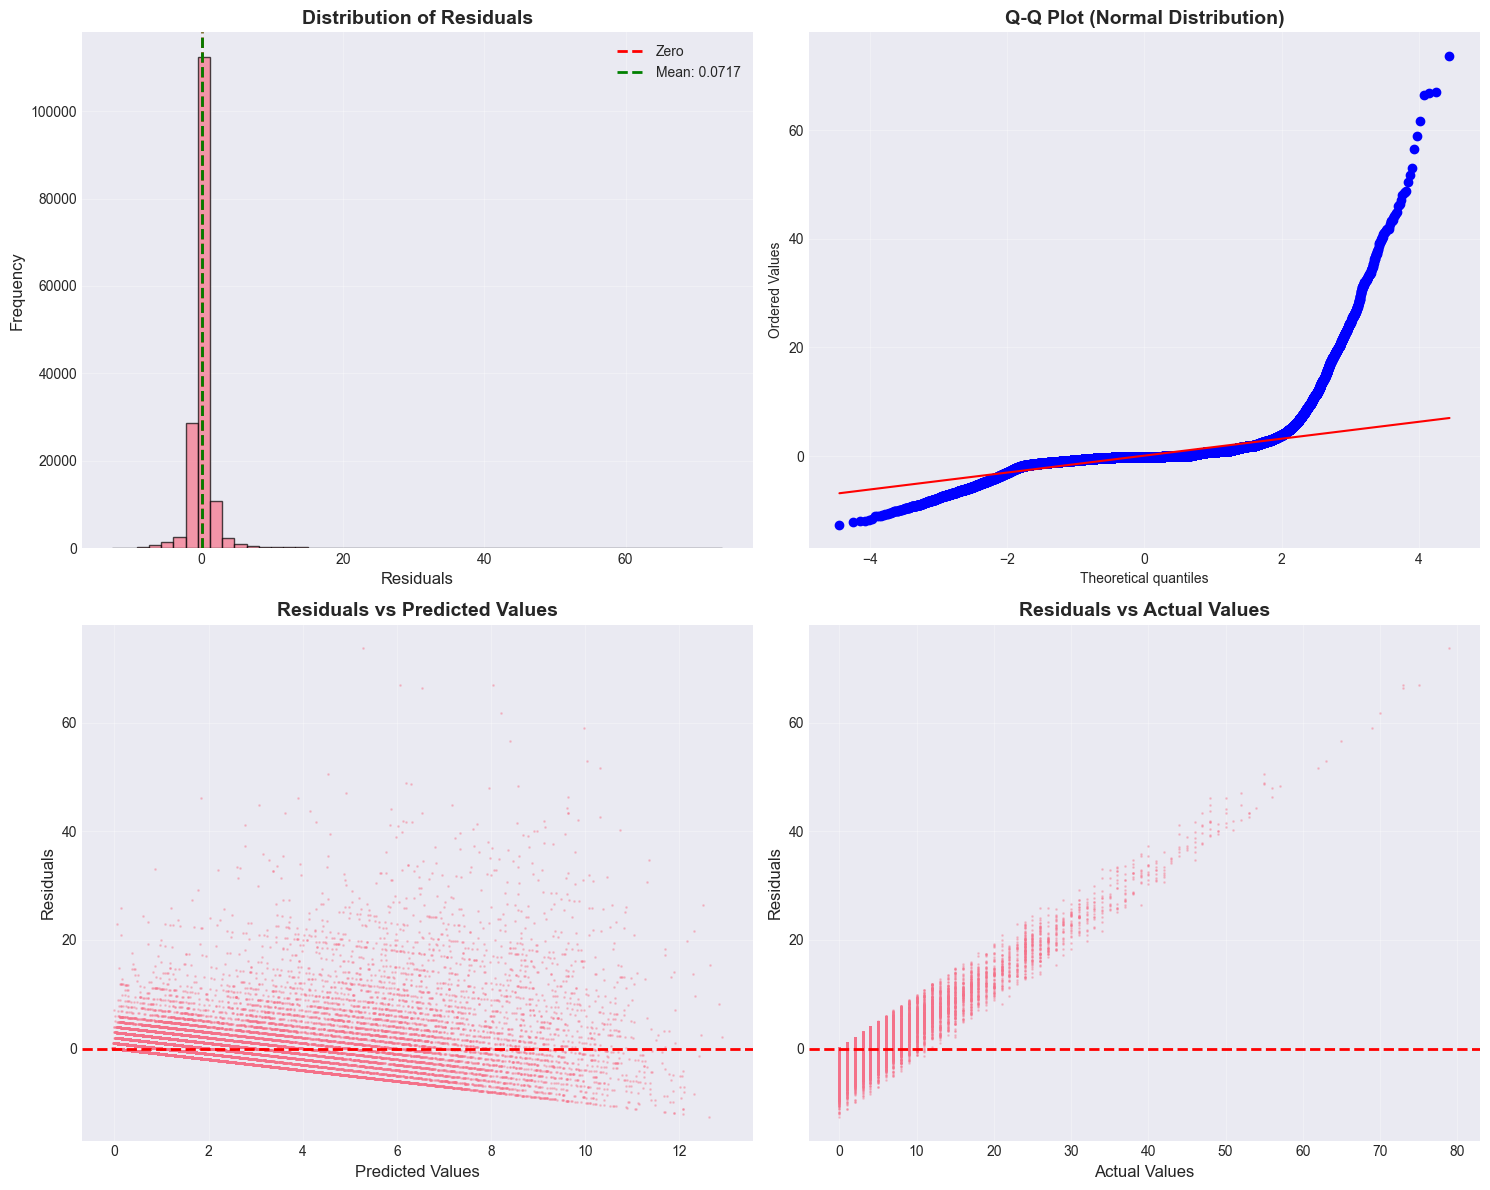

✅ Residuals анализ визуализация запазена: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/residuals_analysis.png


In [12]:
# Визуализация на residuals
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram на residuals
axes[0, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0, 0].axvline(np.mean(residuals), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(residuals):.4f}')
axes[0, 0].set_xlabel('Residuals', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot за проверка на нормалност
from scipy.stats import probplot
probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normal Distribution)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals vs Predicted values
axes[1, 0].scatter(y_pred, residuals, alpha=0.3, s=1)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Values', fontsize=12)
axes[1, 0].set_ylabel('Residuals', fontsize=12)
axes[1, 0].set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals vs Actual values
axes[1, 1].scatter(y_test, residuals, alpha=0.3, s=1)
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Actual Values', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].set_title('Residuals vs Actual Values', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EVALUATION_VIZ_DIR / "residuals_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Residuals анализ визуализация запазена: {MODELS_DIR / 'residuals_analysis.png'}")


### 3.1. Интерпретация на residuals анализа

**Distribution of Residuals:**
- Ако residuals са симетрично разпределени около 0 → моделът няма систематичен bias
- Ако има асиметрия → моделът систематично подценява или надценява прогнозите

**Q-Q Plot:**
- Ако точките следват правата линия → residuals следват нормално разпределение
- Отклонения от правата линия → наличието на outliers или не-нормално разпределение

**Residuals vs Predicted/Actual Values:**
- Ако residuals са разпръснати равномерно около 0 → моделът работи добре за всички стойности
- Ако има модел (напр. воронка) → моделът има различна точност за различни диапазони
- Големи outliers → области, където моделът не успява да прогнозира правилно


## 4. Анализ на стабилност и confidence intervals

Проверяваме стабилността на модела чрез различни random seeds или различни train/validation splits. Моделът се тренира няколко пъти, за да се провери стабилността на прогнозите.

**Метрики за оценка:**
- Средна стойност и стандартно отклонение на MSE/MAE/RMSE при различни изпълнения
- Ако резултатите са силно променливи → моделът е нестабилен, което може да е проблем за production


🔄 Извършване на bootstrap анализ за стабилност...

📊 Bootstrap статистики (100 итерации):

   MSE:
      Mean: 5.0712
      Std:  0.1254
      95% CI: [4.8393, 5.3239]
      Coefficient of Variation: 2.47%

   MAE:
      Mean: 0.9019
      Std:  0.0048
      95% CI: [0.8928, 0.9116]
      Coefficient of Variation: 0.54%

   RMSE:
      Mean: 2.2518
      Std:  0.0278
      95% CI: [2.1998, 2.3074]
      Coefficient of Variation: 1.23%

   WAPE:
      Mean: 60.2992
      Std:  0.1994
      95% CI: [59.9254, 60.6811]
      Coefficient of Variation: 0.33%



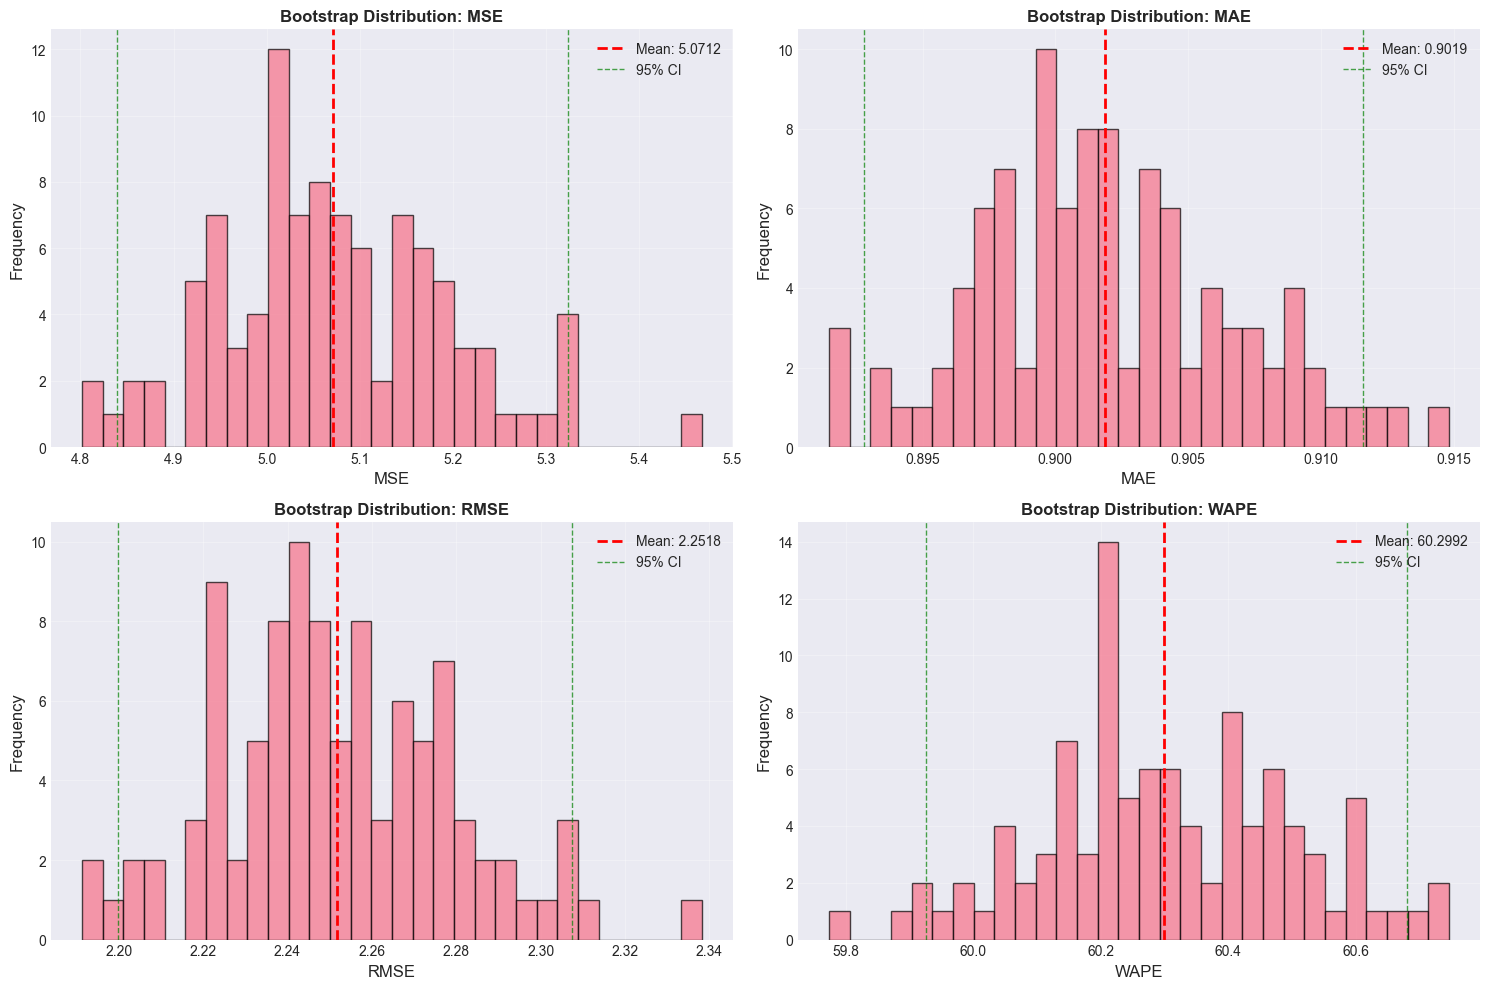

✅ Стабилност анализ визуализация запазена: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/stability_analysis.png

📈 Оценка на стабилността:
   Coefficient of Variation (CV) за RMSE: 1.23%
   ✅ Моделът е много стабилен (CV < 5%)


In [13]:
# Забележка: За пълна стабилност анализа трябва да обучим модела няколко пъти с различни seeds
# Това е скъпо по време, затова ще направим bootstrap анализ върху прогнозите

def bootstrap_metrics(y_true, y_pred, n_bootstrap=100, random_state=42):
    """Bootstrap анализ за оценка на стабилността на метриките"""
    np.random.seed(random_state)
    
    n_samples = len(y_true)
    metrics_list = []
    
    for i in range(n_bootstrap):
        # Bootstrap sample
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]
        
        # Изчисляване на метрики
        mse = mean_squared_error(y_true_boot, y_pred_boot)
        mae = mean_absolute_error(y_true_boot, y_pred_boot)
        rmse = np.sqrt(mse)
        wape = calculate_wape(y_true_boot, y_pred_boot)
        
        metrics_list.append({
            'MSE': mse,
            'MAE': mae,
            'RMSE': rmse,
            'WAPE': wape if not np.isnan(wape) else None
        })
    
    return pd.DataFrame(metrics_list)

print("🔄 Извършване на bootstrap анализ за стабилност...")
bootstrap_results = bootstrap_metrics(y_test, y_pred, n_bootstrap=100)

# Статистики за всяка метрика
print("\n📊 Bootstrap статистики (100 итерации):\n")
for metric in ['MSE', 'MAE', 'RMSE', 'WAPE']:
    if metric in bootstrap_results.columns:
        values = bootstrap_results[metric].dropna()
        if len(values) > 0:
            mean_val = values.mean()
            std_val = values.std()
            ci_lower = values.quantile(0.025)
            ci_upper = values.quantile(0.975)
            
            print(f"   {metric}:")
            print(f"      Mean: {mean_val:.4f}")
            print(f"      Std:  {std_val:.4f}")
            print(f"      95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
            print(f"      Coefficient of Variation: {(std_val/mean_val)*100:.2f}%")
            print()

# Визуализация на bootstrap разпределения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['MSE', 'MAE', 'RMSE', 'WAPE']
for idx, metric in enumerate(metrics_to_plot):
    row = idx // 2
    col = idx % 2
    
    if metric in bootstrap_results.columns:
        values = bootstrap_results[metric].dropna()
        if len(values) > 0:
            axes[row, col].hist(values, bins=30, edgecolor='black', alpha=0.7)
            axes[row, col].axvline(values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {values.mean():.4f}')
            axes[row, col].axvline(values.quantile(0.025), color='green', linestyle='--', linewidth=1, alpha=0.7, label='95% CI')
            axes[row, col].axvline(values.quantile(0.975), color='green', linestyle='--', linewidth=1, alpha=0.7)
            axes[row, col].set_xlabel(metric, fontsize=12)
            axes[row, col].set_ylabel('Frequency', fontsize=12)
            axes[row, col].set_title(f'Bootstrap Distribution: {metric}', fontsize=12, fontweight='bold')
            axes[row, col].legend()
            axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EVALUATION_VIZ_DIR / "stability_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Стабилност анализ визуализация запазена: {MODELS_DIR / 'stability_analysis.png'}")

# Оценка на стабилността
cv_rmse = bootstrap_results['RMSE'].std() / bootstrap_results['RMSE'].mean()
print(f"\n📈 Оценка на стабилността:")
print(f"   Coefficient of Variation (CV) за RMSE: {cv_rmse*100:.2f}%")
if cv_rmse < 0.05:
    print("   ✅ Моделът е много стабилен (CV < 5%)")
elif cv_rmse < 0.10:
    print("   ✅ Моделът е стабилен (CV < 10%)")
else:
    print("   ⚠️  Моделът може да е нестабилен (CV >= 10%)")


## 5. Сравнение с baseline модели

Baseline моделите са прости подходи, които служат като референция. Ако MLP не показва значително подобрение → вероятно архитектурата или признаците не са достатъчно информативни.

**Baseline модели:**
1. **Naive Forecast** - прогноза на последната реална стойност
2. **Moving Average** - средна стойност на последните N дни
3. **Linear Regression** - проста линейна регресия


In [14]:
# Забележка: За пълно сравнение с baseline трябва да имаме достъп до train данните
# За сега ще използваме само test данните и ще направим прости baseline прогнози

# Зареждане на train данни за baseline модели
with open(processed_data_path, "rb") as f:
    data_full = pickle.load(f)

X_train_scaled = data_full["X_train_scaled"]
y_train = data_full["y_train"]
X_val_scaled = data_full["X_val_scaled"]
y_val = data_full["y_val"]

if isinstance(X_train_scaled, pd.DataFrame):
    X_train_scaled = X_train_scaled.values
    X_val_scaled = X_val_scaled.values
if isinstance(y_train, pd.Series):
    y_train = y_train.values
    y_val = y_val.values

X_train_scaled = X_train_scaled.astype("float32")
y_train = y_train.astype("float32")

print("📊 Създаване на baseline модели...\n")

# 1. Naive Forecast (последната стойност)
# За тест данните използваме средната стойност от train данните като naive прогноза
naive_pred = np.full_like(y_test, np.mean(y_train))
naive_rmse = calculate_rmse(y_test, naive_pred)
naive_mae = calculate_mae(y_test, naive_pred)
naive_wape = calculate_wape(y_test, naive_pred)

print("1️⃣  Naive Forecast (средна стойност от train):")
print(f"   RMSE: {naive_rmse:.4f}")
print(f"   MAE:  {naive_mae:.4f}")
print(f"   WAPE: {naive_wape:.4f}%")

# 2. Linear Regression
print("\n2️⃣  Linear Regression:")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_rmse = calculate_rmse(y_test, lr_pred)
lr_mae = calculate_mae(y_test, lr_pred)
lr_wape = calculate_wape(y_test, lr_pred)

print(f"   RMSE: {lr_rmse:.4f}")
print(f"   MAE:  {lr_mae:.4f}")
print(f"   WAPE: {lr_wape:.4f}%")

# 3. MLP модел (за сравнение)
mlp_rmse = metrics["RMSE"]
mlp_mae = metrics["MAE"]
mlp_wape = metrics["WAPE"]

print("\n3️⃣  MLP Model:")
print(f"   RMSE: {mlp_rmse:.4f}")
print(f"   MAE:  {mlp_mae:.4f}")
print(f"   WAPE: {mlp_wape:.4f}%")

# Сравнение
print("\n📊 Сравнение на моделите:\n")
comparison_df = pd.DataFrame({
    'Model': ['Naive Forecast', 'Linear Regression', 'MLP'],
    'RMSE': [naive_rmse, lr_rmse, mlp_rmse],
    'MAE': [naive_mae, lr_mae, mlp_mae],
    'WAPE': [naive_wape, lr_wape, mlp_wape]
})

print(comparison_df.to_string(index=False))

# Изчисляване на подобрение спрямо baseline
improvement_vs_naive = ((naive_rmse - mlp_rmse) / naive_rmse) * 100
improvement_vs_lr = ((lr_rmse - mlp_rmse) / lr_rmse) * 100

print(f"\n📈 Подобрение на MLP спрямо baseline:")
print(f"   vs Naive Forecast: {improvement_vs_naive:.2f}% намаление на RMSE")
print(f"   vs Linear Regression: {improvement_vs_lr:.2f}% намаление на RMSE")

if improvement_vs_naive > 10:
    print("   ✅ MLP показва значително подобрение спрямо Naive Forecast")
else:
    print("   ⚠️  MLP не показва значително подобрение спрямо Naive Forecast")

if improvement_vs_lr > 5:
    print("   ✅ MLP показва подобрение спрямо Linear Regression")
else:
    print("   ⚠️  MLP не показва значително подобрение спрямо Linear Regression")

# Запазване на сравнението
comparison_df.to_csv(EVALUATION_METRICS_DIR / "baseline_comparison.csv", index=False)
print(f"\n✅ Сравнението е запазено в: {MODELS_DIR / 'baseline_comparison.csv'}")


📊 Създаване на baseline модели...

1️⃣  Naive Forecast (средна стойност от train):
   RMSE: 2.7956
   MAE:  1.1954
   WAPE: 72.7335%

2️⃣  Linear Regression:
   RMSE: 2.7809
   MAE:  1.1681
   WAPE: 71.6318%

3️⃣  MLP Model:
   RMSE: 2.2472
   MAE:  0.9015
   WAPE: 60.2911%

📊 Сравнение на моделите:

            Model     RMSE      MAE      WAPE
   Naive Forecast 2.795630 1.195384 72.733513
Linear Regression 2.780922 1.168118 71.631775
              MLP 2.247204 0.901461 60.291119

📈 Подобрение на MLP спрямо baseline:
   vs Naive Forecast: 19.62% намаление на RMSE
   vs Linear Regression: 19.19% намаление на RMSE
   ✅ MLP показва значително подобрение спрямо Naive Forecast
   ✅ MLP показва подобрение спрямо Linear Regression

✅ Сравнението е запазено в: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/baseline_comparison.csv


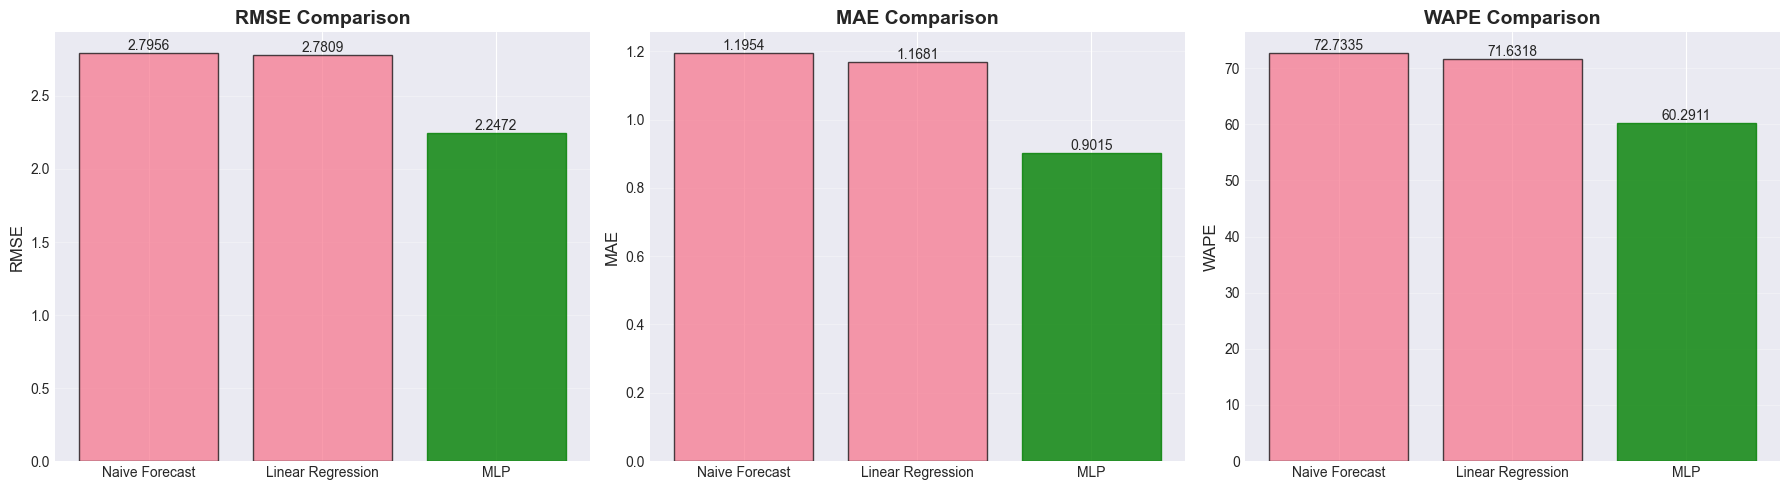

✅ Сравнение визуализация запазена: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/baseline_comparison.png


In [15]:
# Визуализация на сравнението
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_compare = ['RMSE', 'MAE', 'WAPE']
for idx, metric in enumerate(metrics_to_compare):
    values = [comparison_df.loc[0, metric], comparison_df.loc[1, metric], comparison_df.loc[2, metric]]
    models = comparison_df['Model'].values
    
    bars = axes[idx].bar(models, values, alpha=0.7, edgecolor='black')
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Оцветяване на най-добрия модел
    best_idx = np.argmin(values)
    bars[best_idx].set_color('green')
    bars[best_idx].set_alpha(0.8)
    
    # Добавяне на стойности върху стълбовете
    for bar, val in zip(bars, values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{val:.4f}',
                      ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(EVALUATION_VIZ_DIR / "baseline_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Сравнение визуализация запазена: {MODELS_DIR / 'baseline_comparison.png'}")


In [16]:
# Бизнес-метрики и анализ

print("💼 Бизнес-интерпретация на резултатите:\n")

# 1. Анализ на грешките по диапазони
print("1️⃣  Анализ на грешките по диапазони на продажби:\n")

# Разделяне на данните по квантили
quantiles = [0, 0.25, 0.5, 0.75, 1.0]
quantile_values = np.quantile(y_test, quantiles)

for i in range(len(quantiles)-1):
    mask = (y_test >= quantile_values[i]) & (y_test < quantile_values[i+1])
    if i == len(quantiles)-2:  # Последният квантил включва и максимума
        mask = (y_test >= quantile_values[i]) & (y_test <= quantile_values[i+1])
    
    subset_y_test = y_test[mask]
    subset_y_pred = y_pred[mask]
    
    if len(subset_y_test) > 0:
        mae_subset = calculate_mae(subset_y_test, subset_y_pred)
        rmse_subset = calculate_rmse(subset_y_test, subset_y_pred)
        mean_actual = subset_y_test.mean()
        
        print(f"   Квантил {quantiles[i]:.0%}-{quantiles[i+1]:.0%} (средна продажба: {mean_actual:.2f}):")
        print(f"      MAE: {mae_subset:.4f}, RMSE: {rmse_subset:.4f}")
        print(f"      Относителна грешка: {(mae_subset/mean_actual)*100:.2f}%")
        print()

# 2. Анализ на големите грешки (outliers)
print("2️⃣  Анализ на големите грешки:\n")
absolute_errors = np.abs(y_test - y_pred)
large_errors_threshold = np.percentile(absolute_errors, 95)
large_errors_mask = absolute_errors >= large_errors_threshold

print(f"   Брой прогнози с големи грешки (top 5%): {large_errors_mask.sum()}")
print(f"   Средна абсолютна грешка за тези случаи: {absolute_errors[large_errors_mask].mean():.4f}")
print(f"   Средна реална стойност за тези случаи: {y_test[large_errors_mask].mean():.4f}")
print(f"   Средна прогнозирана стойност: {y_pred[large_errors_mask].mean():.4f}")

# 3. Анализ на подценяване/надценяване
print("\n3️⃣  Анализ на подценяване/надценяване:\n")
underestimation = (y_pred < y_test).sum()
overestimation = (y_pred > y_test).sum()
equal = (np.abs(y_pred - y_test) < 1e-6).sum()

print(f"   Подценяване (pred < actual): {underestimation} ({underestimation/len(y_test)*100:.2f}%)")
print(f"   Надценяване (pred > actual): {overestimation} ({overestimation/len(y_test)*100:.2f}%)")
print(f"   Равни: {equal} ({equal/len(y_test)*100:.2f}%)")

mean_underestimation_error = np.mean(y_test[y_pred < y_test] - y_pred[y_pred < y_test]) if underestimation > 0 else 0
mean_overestimation_error = np.mean(y_pred[y_pred > y_test] - y_test[y_pred > y_test]) if overestimation > 0 else 0

print(f"\n   Средна грешка при подценяване: {mean_underestimation_error:.4f}")
print(f"   Средна грешка при надценяване: {mean_overestimation_error:.4f}")

# 4. Практическа приложимост
print("\n4️⃣  Практическа приложимост:\n")
mean_sales = y_test.mean()
mae_relative = (metrics["MAE"] / mean_sales) * 100 if mean_sales > 0 else np.nan

print(f"   Средна продажба: {mean_sales:.4f}")
print(f"   MAE като процент от средната продажба: {mae_relative:.2f}%")

if mae_relative < 10:
    print("   ✅ Грешката е малка спрямо средната продажба - моделът е практичен")
elif mae_relative < 20:
    print("   ⚠️  Грешката е умерена - моделът може да е полезен с допълнителна валидация")
else:
    print("   ⚠️  Грешката е голяма - моделът може да не е достатъчно точен за production")

# 5. Влияние върху бизнес решения
print("\n5️⃣  Влияние върху бизнес решения:\n")
print("   За управление на наличности:")
print(f"   - Средна грешка от {metrics['MAE']:.2f} единици може да доведе до:")
print(f"     * Недостатъчни наличности при подценяване")
print(f"     * Излишък от наличности при надценяване")
print(f"   - RMSE от {metrics['RMSE']:.2f} показва, че има случаи с по-големи отклонения")

# Запазване на бизнес анализа
business_analysis = {
    "mean_sales": float(mean_sales),
    "mae_relative_percent": float(mae_relative) if not np.isnan(mae_relative) else None,
    "underestimation_percent": float(underestimation/len(y_test)*100),
    "overestimation_percent": float(overestimation/len(y_test)*100),
    "large_errors_count": int(large_errors_mask.sum()),
    "large_errors_percent": float(large_errors_mask.sum()/len(y_test)*100)
}

with open(EVALUATION_REPORTS_DIR / "business_analysis.json", "w") as f:
    json.dump(business_analysis, f, indent=2)

print(f"\n✅ Бизнес анализът е запазен в: {MODELS_DIR / 'business_analysis.json'}")


💼 Бизнес-интерпретация на резултатите:

1️⃣  Анализ на грешките по диапазони на продажби:

   Квантил 50%-75% (средна продажба: 0.00):
      MAE: 0.4922, RMSE: 0.9604
      Относителна грешка: inf%

   Квантил 75%-100% (средна продажба: 2.78):
      MAE: 1.6774, RMSE: 3.5884
      Относителна грешка: 60.29%

2️⃣  Анализ на големите грешки:

   Брой прогнози с големи грешки (top 5%): 8108
   Средна абсолютна грешка за тези случаи: 7.1404
   Средна реална стойност за тези случаи: 7.6127
   Средна прогнозирана стойност: 4.7603

3️⃣  Анализ на подценяване/надценяване:

   Подценяване (pred < actual): 43300 (26.70%)
   Надценяване (pred > actual): 118855 (73.30%)
   Равни: 0 (0.00%)

   Средна грешка при подценяване: 1.8221
   Средна грешка при надценяване: 0.5661

4️⃣  Практическа приложимост:

   Средна продажба: 0.9606
   MAE като процент от средната продажба: 93.84%
   ⚠️  Грешката е голяма - моделът може да не е достатъчно точен за production

5️⃣  Влияние върху бизнес решения:

   За 

## 7. Резюме и заключения

Обобщение на всички резултати от оценката на модела.


In [18]:
# Създаване на пълно резюме
print("="*80)
print("📊 РЕЗЮМЕ НА ОЦЕНКАТА НА МОДЕЛА")
print("="*80)

print("\n1️⃣  REGRESSION МЕТРИКИ:")
print(f"   RMSE:   {metrics['RMSE']:.4f}")
print(f"   MAE:    {metrics['MAE']:.4f}")
print(f"   WAPE:   {metrics['WAPE']:.4f}%")
print(f"   WRMSSE: {metrics['WRMSSE']:.4f}%")

print("\n2️⃣  RESIDUALS АНАЛИЗ:")
print(f"   Средна стойност: {residuals_stats['Mean']:.6f}")
print(f"   Стандартно отклонение: {residuals_stats['Std']:.4f}")
if abs(residuals_stats['Mean']) < 0.01:
    print("   ✅ Няма значителен систематичен bias")
else:
    print(f"   ⚠️  Има систематичен bias: {residuals_stats['Mean']:.6f}")

print("\n3️⃣  СТАБИЛНОСТ:")
if 'cv_rmse' in locals():
    print(f"   Coefficient of Variation (CV) за RMSE: {cv_rmse*100:.2f}%")
    if cv_rmse < 0.05:
        print("   ✅ Моделът е много стабилен")
    elif cv_rmse < 0.10:
        print("   ✅ Моделът е стабилен")
    else:
        print("   ⚠️  Моделът може да е нестабилен")

print("\n4️⃣  СРАВНЕНИЕ С BASELINE:")
print(f"   Подобрение спрямо Naive Forecast: {improvement_vs_naive:.2f}%")
print(f"   Подобрение спрямо Linear Regression: {improvement_vs_lr:.2f}%")

print("\n5️⃣  БИЗНЕС-ИНТЕРПРЕТАЦИЯ:")
if 'mae_relative' in locals() and not np.isnan(mae_relative):
    print(f"   MAE като процент от средната продажба: {mae_relative:.2f}%")
    if mae_relative < 10:
        print("   ✅ Моделът е практичен за използване")
    elif mae_relative < 20:
        print("   ⚠️  Моделът може да е полезен с допълнителна валидация")
    else:
        print("   ⚠️  Моделът може да не е достатъчно точен")

print("\n" + "="*80)
print("✅ ОЦЕНКАТА Е ЗАВЪРШЕНА")
print("="*80)

# Запазване на пълното резюме
# Конвертиране на всички numpy типове към стандартни Python типове за JSON сериализация
def convert_to_serializable(obj):
    """Рекурсивно конвертира numpy типове към стандартни Python типове"""
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    elif obj is None or isinstance(obj, (str, int, float, bool)):
        return obj
    else:
        return str(obj)  # Fallback за неизвестни типове

summary = {
    "metrics": convert_to_serializable(metrics),
    "residuals_stats": convert_to_serializable(residuals_stats),
    "stability": {
        "cv_rmse_percent": float(cv_rmse*100) if 'cv_rmse' in locals() else None
    },
    "baseline_comparison": {
        "improvement_vs_naive_percent": float(improvement_vs_naive) if 'improvement_vs_naive' in locals() else None,
        "improvement_vs_lr_percent": float(improvement_vs_lr) if 'improvement_vs_lr' in locals() else None
    },
    "business_analysis": convert_to_serializable(business_analysis) if 'business_analysis' in locals() else {}
}

with open(EVALUATION_REPORTS_DIR / "evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"\n📄 Пълното резюме е запазено в: {MODELS_DIR / 'evaluation_summary.json'}")


📊 РЕЗЮМЕ НА ОЦЕНКАТА НА МОДЕЛА

1️⃣  REGRESSION МЕТРИКИ:
   RMSE:   2.2472
   MAE:    0.9015
   WAPE:   60.2911%
   WRMSSE: 233.9302%

2️⃣  RESIDUALS АНАЛИЗ:
   Средна стойност: 0.071656
   Стандартно отклонение: 2.2461
   ⚠️  Има систематичен bias: 0.071656

3️⃣  СТАБИЛНОСТ:
   Coefficient of Variation (CV) за RMSE: 1.23%
   ✅ Моделът е много стабилен

4️⃣  СРАВНЕНИЕ С BASELINE:
   Подобрение спрямо Naive Forecast: 19.62%
   Подобрение спрямо Linear Regression: 19.19%

5️⃣  БИЗНЕС-ИНТЕРПРЕТАЦИЯ:
   MAE като процент от средната продажба: 93.84%
   ⚠️  Моделът може да не е достатъчно точен

✅ ОЦЕНКАТА Е ЗАВЪРШЕНА

📄 Пълното резюме е запазено в: /Users/filipapopova/source/repos/2526-12b-feedforwardneuralnetwork-hierarchical-demand-forecasting/models/evaluation_summary.json
